In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import pandas as pd
import pickle
from matplotlib import cm
from scipy.stats import sem, ttest_1samp, pearsonr, linregress, f_oneway, friedmanchisquare
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
def to_day(di):
    if di >= 2:
        return "Day6"
    else:
        return "Day" + str(di + 1)

In [3]:
um = 0.31 # pixel per length (μm)

In [4]:
img = []
for mi in range(6):
    mouse = "mouse" + str(mi + 1)
    imgs = []
    img_pil = Image.open("footprint/" + mouse + ".tif")
    for i in range(img_pil.n_frames):
        img_pil.seek(i)
        imgs.append(np.asarray(img_pil))
    img.append(np.array(imgs))

In [5]:
with open("w_single.pkl", "rb") as f:
    w = pickle.load(f)
with open("loc_vecs.pkl", "rb") as f:
    loc_vecs = pickle.load(f)
with open("loc_vecs_inv.pkl", "rb") as f:
    loc_vecs_inv = pickle.load(f)

In [6]:
wr = []
for mi in range(6):
    wr_s = []
    for di in range(3):
        w_mean = w[mi][di][:, :, 0].mean(axis=0).reshape(1, -1)
        w_std = w[mi][di][:, :, 0].std(axis=0).reshape(1, -1)
        wr_s.append((w[mi][di][:, :, 0] - w_mean) / w_std)
    wr.append(wr_s)

In [7]:
lv = []
lv_inv = []
for mi in range(6):
    lv_s = []
    lv_inv_s = []
    for di in range(3):
        lv_flat = loc_vecs[mi][di].reshape(loc_vecs[mi][di].shape[0], -1)
        lv_mean = lv_flat.mean(axis=-1).reshape(-1, 1, 1)
        lv_std = lv_flat.std(axis=-1).reshape(-1, 1, 1)
        lv_s.append((loc_vecs[mi][di] - lv_mean) / lv_std)
        lv_inv_s.append((loc_vecs_inv[mi][di] - lv_mean) / lv_std)
    lv.append(lv_s)
    lv_inv.append(lv_inv_s)

In [8]:
mi = 4
ext_size = 2 # extension size
n, y, x = img[mi].shape
edg_small = np.zeros_like((img[mi])) # cell edges (image size)
for ci in range(n):
    ys, xs = np.where(img[mi][ci] > 0)
    for yi, xi in zip(ys, xs):
        if np.sum(img[mi][ci, max(0, yi-1):min(yi+2,y), max(0, xi-1):min(xi+2,x)] == 0)>=3:
            edg_small[ci, yi, xi] = 1
            
big = np.zeros((n, ext_size*y, ext_size*x)) # extended image
val = np.zeros_like(big) # cell regions of extended image
edg = np.zeros_like(big) # cell edges (extended image size)

edg_tmp = np.zeros_like(big)
for yi in range(ext_size):
    for xi in range(ext_size):
        big[:, yi:ext_size*y:ext_size, xi:ext_size*x:ext_size] = img[mi][:, :, :]
        edg_tmp[:, yi:ext_size*y:ext_size, xi:ext_size*x:ext_size] = edg_small[:, :, :]
n, y, x = big.shape
for ci in range(n):
    ys, xs = np.where(edg_tmp[ci] > 0)
    for yi, xi in zip(ys, xs):
        if np.sum(big[ci, max(0, yi-1):min(yi+2,y), max(0, xi-1):min(xi+2,x)] == 0)>=3:
            edg[ci, yi, xi] = 1
val[big > 0] = 1

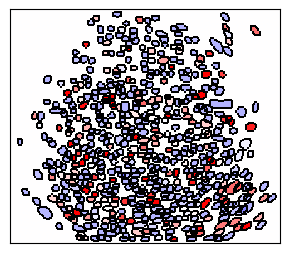

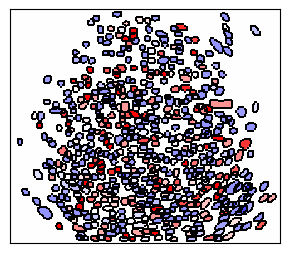

In [9]:
mi = 4
di = 2
cmap = cm.bwr
cmap.set_bad(color="k")
for ki in [1, 4]:
    tmp_plot = np.sum(val * wr[mi][di][:, ki:ki+1, np.newaxis], axis=0)
    tmp_plot[np.any(edg, axis=0)] = np.nan
    fig = plt.figure(figsize=(3, 3))
    ax = fig.add_subplot(1, 1, 1)#, aspect="equal")
    ax.imshow(tmp_plot, cmap=cmap, vmin=-2, vmax=2)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    plt.tight_layout()
    plt.savefig("figures/fig8/fig8a_Seq" + str(ki+1) + ".png")
    plt.show()

In [10]:
res = np.zeros((6, 3, 6))
for mi in range(6):
    n, y, x = img[mi].shape
    centre = np.zeros((n, 2))
    dist = np.zeros((n, n))
    for ci in range(n):
        gx = np.sum(img[mi][ci, :, :].sum(axis=0) * np.arange(x)) / img[mi][ci, :, :].sum()
        gy = np.sum(img[mi][ci, :, :].sum(axis=1) * np.arange(y)) / img[mi][ci, :, :].sum()
        centre[ci, :] = [gy, gx]
    for i in range(n):
        for j in range(i+1, n):
            dist[i, j] = np.sqrt(np.square(centre[i] - centre[j]).sum()) / um
            dist[j, i] = dist[i, j]
    for di in range(3):
        wi = w[mi][di][:, :, 0]
        _, k = wi.shape
        N = n * (n - 1) // 2
        act = np.zeros((N, k, 2))
        c = 0
        for i in range(n):
            for j in range(i+1, n):
                act[c, :, 0] = dist[i, j]
                act[c, :, 1] = np.abs(wr[mi][di][i, :] - wr[mi][di][j, :])
                c += 1
        act = act.reshape(-1, 2)
        res[mi, di, 0] = act[act[:, 0] < 90, 1].mean()
        for i in range(1, 5):
            res[mi, di, i] = act[(act[:, 0] >= 90 * i) & (act[:, 1] < 90 * (i + 1)), 1].mean()
        res[mi, di, 5] = act[act[:, 0] >= 450, 1].mean()

Day1
   min  max    mean     std
0    0   90  0.9347  0.0311
1   90  180  0.9196  0.0295
2  180  270  0.9151  0.0291
3  270  360  0.9045  0.0279
4  360  450  0.8877  0.0267
5  450  540  0.8624  0.0262
Day2
   min  max    mean     std
0    0   90  0.9255  0.0329
1   90  180  0.9110  0.0362
2  180  270  0.9057  0.0371
3  270  360  0.8941  0.0388
4  360  450  0.8778  0.0413
5  450  540  0.8502  0.0443
Day6
   min  max    mean     std
0    0   90  0.9220  0.0360
1   90  180  0.9091  0.0360
2  180  270  0.9058  0.0361
3  270  360  0.8992  0.0357
4  360  450  0.8900  0.0355
5  450  540  0.8787  0.0347


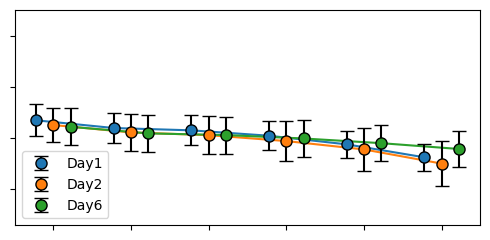

In [11]:
se = sem(res, axis=0)
plt.figure(figsize=(5, 2.5))
pd.options.display.precision = 4
for di in range(3):
    x = np.arange(6) * 90 + 45 + (di - 1) * 20
    y = res[:, di, :].mean(axis=0)
    yerr = se[di, :]
    print(to_day(di))
    print(pd.DataFrame({
        "min": np.arange(6) * 90,
        "max": np.arange(1, 7) * 90,
        "mean": y,
        "std": yerr
    }))
    plt.plot(x, y, zorder=0)
    plt.errorbar(x=x, y=y, fmt="o", yerr=yerr, ecolor="black", color="C"+str(di), markeredgecolor="black", markersize=8, capsize=5, zorder=1, label=to_day(di))
plt.legend(loc="lower left")
plt.xticks(np.arange(6) * 90 + 45)
plt.ylim(0.73, 1.15)
plt.yticks([0.8, 0.9, 1.0, 1.1])
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/fig8/fig8b.png")

In [12]:
p_vals = []
c_vals = []
for di in range(3):
    df = pd.DataFrame({
        "act": res[:, di, :].T.reshape(-1),
        "dist": np.repeat(np.arange(6) * 90 + 45, 6),
    })
    f_res = friedmanchisquare(
        res[:, di, 0], res[:, di, 1], res[:, di, 2], 
        res[:, di, 3], res[:, di, 4], res[:, di, 5], 
    )
    p_vals.append(f_res.pvalue)
    c_vals.append(f_res.statistic)
p_cors = multipletests(p_vals, alpha=0.05, method="bonferroni")[1]
for di in range(3):
    print("{} | c = {:.4f} | p = {:.4f}".format(to_day(di), c_vals[di], p_cors[di]))

Day1 | c = 30.0000 | p = 0.0000
Day2 | c = 30.0000 | p = 0.0000
Day6 | c = 13.3333 | p = 0.0613


In [13]:
norm_cell = [[np.sqrt(np.square(wr[mi][di][:, :]).sum(axis=0)) for di in range(3)] for mi in range(6)]
norm_lv = [[np.sqrt(np.square(lv[mi][di]).sum(axis=-1)) for di in range(3)] for mi in range(6)]
res = []
for di in range(3):
    dj = (di + 1) % 3
    res_s = []
    for mi in range(6):
        k1 = w[mi][di].shape[1]
        k2 = w[mi][dj].shape[1]
        save = np.zeros((k1*k2, 3))
        for ki in range(k1):
            for kj in range(k2):
                save[ki*k2+kj, 0] = (wr[mi][di][:, ki] * wr[mi][dj][:, kj]).sum() / (norm_cell[mi][di][ki] * norm_cell[mi][dj][kj])
                save[ki*k2+kj, 1] = ((lv[mi][di][ki] * lv[mi][dj][kj]).sum(axis=-1) / (norm_lv[mi][di][ki] * norm_lv[mi][dj][kj])).mean()
                save[ki*k2+kj, 2] = ((lv[mi][di][ki] * lv_inv[mi][dj][kj]).sum(axis=-1) / (norm_lv[mi][di][ki] * norm_lv[mi][dj][kj])).mean()
        res_s.append(save)
    res.append(res_s)

Day1, loc | n=260, slope=0.1343±0.0235, intercept=0.0186±0.0079, corrcoef=0.3350, p=0.0000


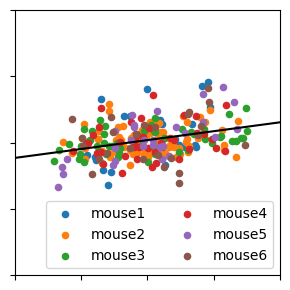

Day1, loc_inv | n=260, slope=0.1328±0.0247, intercept=0.0187±0.0079, corrcoef=0.3168, p=0.0000


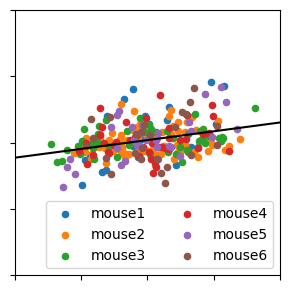

Day2, loc | n=248, slope=0.0599±0.0246, intercept=0.0151±0.0073, corrcoef=0.1535, p=0.0155


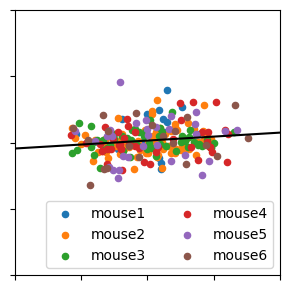

Day2, loc_inv | n=248, slope=0.0680±0.0263, intercept=0.0156±0.0073, corrcoef=0.1626, p=0.0103


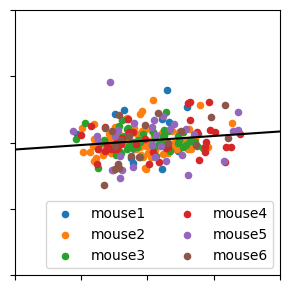

Day6, loc | n=252, slope=0.0320±0.0235, intercept=0.0125±0.0063, corrcoef=0.0860, p=0.1734


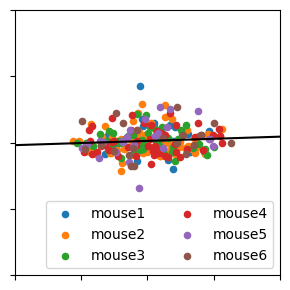

Day6, loc_inv | n=252, slope=0.0375±0.0238, intercept=0.0127±0.0063, corrcoef=0.0989, p=0.1172


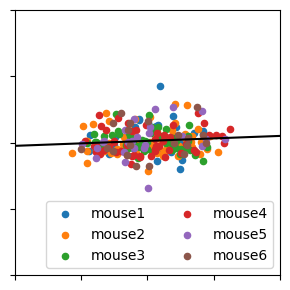

In [14]:
rs = np.zeros((3, 2))
for di in range(3):
    for li, loc in enumerate(["loc", "loc_inv"]):
        rd = np.vstack(res[di])
        lr = linregress(rd[:, li+1], rd[:, 0])
        a = lr.slope
        b = lr.intercept
        print("{}, {} | n={}, slope={:.4f}±{:.4f}, intercept={:.4f}±{:.4f}, corrcoef={:.4f}, p={:.4f}".format(
            to_day(di), loc, len(rd), 
            lr.slope, lr.stderr,
            lr.intercept, lr.intercept_stderr,
            lr.rvalue, lr.pvalue
        ))
        rs[di, li] = lr.rvalue
        fig = plt.figure(figsize=(3, 3))
        ax = fig.add_subplot(1, 1, 1, aspect="equal")
        for mi in range(6):
            ax.scatter(res[di][mi][:, li+1], res[di][mi][:, 0], label="mouse" + str(mi + 1), zorder=0, s=20)
        ax.plot([-1, 1], [a*-1+b, a+b], c="k", zorder=1)
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_xticks([-1, -0.5, 0, 0.5, 1])
        ax.set_yticks([-1, -0.5, 0, 0.5, 1])
        ax.legend(loc="lower right", ncol=2)
        plt.tick_params(labelleft=False, labelbottom=False)
        plt.tight_layout()
        plt.savefig("figures/fig8/fig8d_{}_{}.png".format(to_day(di), loc))
        plt.show()

In [15]:
n_shuffle = 1000
cr = np.zeros((n_shuffle, 3, 2))
for i in range(n_shuffle):
    np.random.seed(i)
    for di in range(3):
        dj = (di + 1) % 3
        cr_d = []
        for mi in range(6):
            n, k1, _ = w[mi][di].shape
            k2 = w[mi][dj].shape[1]
            wr1 = np.vstack([wr[mi][di][np.random.rand(n).argsort(), ki] for ki in range(k1)]).T
            wr2 = np.vstack([wr[mi][dj][np.random.rand(n).argsort(), ki] for ki in range(k2)]).T
            save = np.zeros((k1*k2, 3))
            for ki in range(k1):
                for kj in range(k2):
                    save[ki*k2+kj, 0] = (wr1[:, ki] * wr2[:, kj]).sum() / (norm_cell[mi][di][ki] * norm_cell[mi][dj][kj])
                    save[ki*k2+kj, 1] = ((lv[mi][di][ki] * lv[mi][dj][kj]).sum(axis=-1) / (norm_lv[mi][di][ki] * norm_lv[mi][dj][kj])).mean()
                    save[ki*k2+kj, 2] = ((lv[mi][di][ki] * lv_inv[mi][dj][kj]).sum(axis=-1) / (norm_lv[mi][di][ki] * norm_lv[mi][dj][kj])).mean()
            cr_d.append(save)
        cr_d = np.vstack(cr_d)
        cr[i, di, 0] = np.corrcoef(cr_d[:, 0], cr_d[:, 1])[0, 1]
        cr[i, di, 1] = np.corrcoef(cr_d[:, 0], cr_d[:, 2])[0, 1]

Day1-Day2 loc Mean+5.36SD


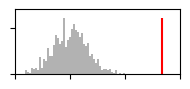

Day1-Day2 loc_inv Mean+5.17SD


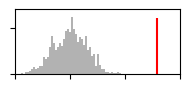

Day2-Day6 loc Mean+2.41SD


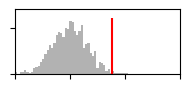

Day2-Day6 loc_inv Mean+2.69SD


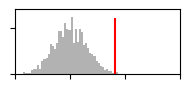

Day6-Day1 loc Mean+1.32SD


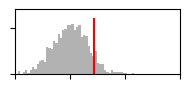

Day6-Day1 loc_inv Mean+1.50SD


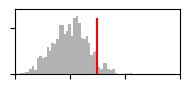

In [16]:
for di in range(3):
    for li, loc in enumerate(["loc", "loc_inv"]):
        dayi = to_day(di)
        dayj = to_day((di+1)%3)
        print("{}-{} {} Mean+{:.2f}SD".format(dayi, dayj, loc, (rs[di, li] - cr[:, di, li].mean()) / cr[:, di, li].std()))
        plt.figure(figsize=(2, 1))
        plt.hist(cr[:, di, li], bins=50, color="k", alpha=0.3)
        plt.vlines(x=rs[di, li], ymin=0, ymax=60, colors="r")
        plt.xlim(-0.2, 0.4)
        plt.ylim(0, 70)
        plt.xticks([-0.2, 0, 0.2, 0.4])
        plt.yticks([0, 50])
        plt.tick_params(labelleft=False, labelbottom=False)
        plt.tight_layout()
        plt.savefig("figures/fig8/fig8f_{}_{}.png".format(dayi, loc))
        plt.show()